Extracting MPS features from image patches...


Starting training optimization using 2D Grid Hamiltonian Loss...
Step:    0 | Total Loss: 0.080998 | Reconstruction MSE: 0.081100 | 2D Energy: -0.010218
Step:   20 | Total Loss: 0.018495 | Reconstruction MSE: 0.019627 | 2D Energy: -0.113202
Step:   40 | Total Loss: 0.011613 | Reconstruction MSE: 0.013818 | 2D Energy: -0.220514
Step:   60 | Total Loss: 0.002338 | Reconstruction MSE: 0.007184 | 2D Energy: -0.484589
Step:   80 | Total Loss: -0.007020 | Reconstruction MSE: 0.004094 | 2D Energy: -1.111398
Step:  100 | Total Loss: -0.017739 | Reconstruction MSE: 0.002654 | 2D Energy: -2.039265
Step:  120 | Total Loss: -0.029074 | Reconstruction MSE: 0.001577 | 2D Energy: -3.065106


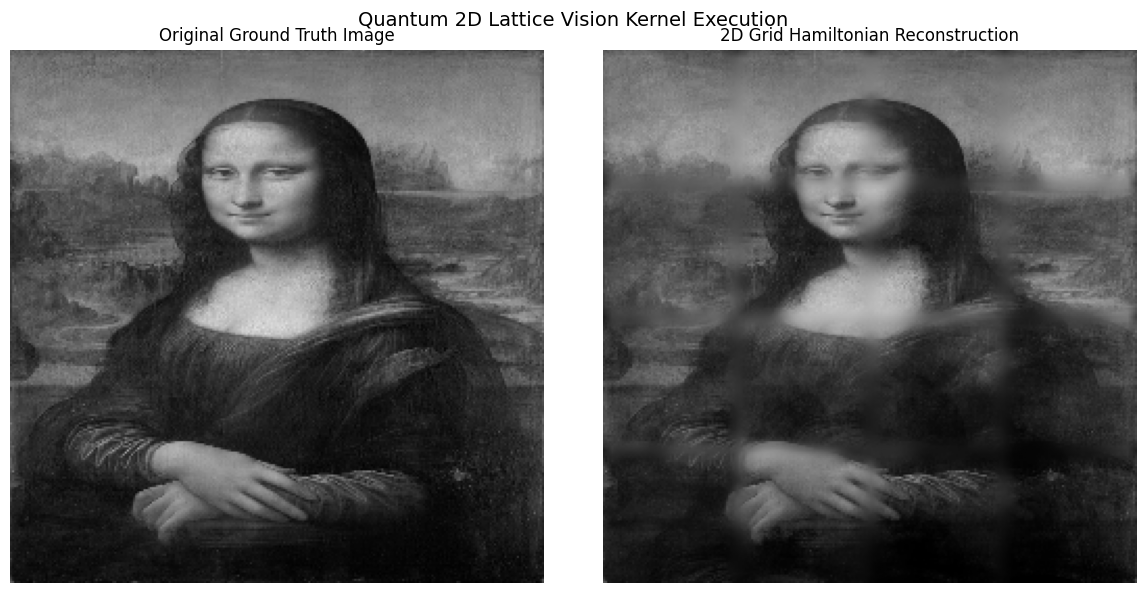

In [6]:
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import quimb.tensor as qtn
import pennylane as qml
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

############################################
# 1. IMAGE LOADING & PATCHING
############################################
try:
    img = cv2.imread("/home/adminpc/Desktop/HVK/Script/Hamiltonian_Vision_Kernel/Main/data/monalisa.jpg", cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256)).astype("float32") / 255.0
except:
    # Synthetic fallback to guarantee execution if the image file is missing
    x = np.linspace(0, 1, 256)
    y = np.linspace(0, 1, 256)
    X, Y = np.meshgrid(x, y)
    img = (np.sin(X * 5) * np.cos(Y * 5) + 1) / 2.0

patch_size = 64
patches, positions_list = [], []

for i in range(0, 256, patch_size):
    for j in range(0, 256, patch_size):
        patches.append(img[i:i+patch_size, j:j+patch_size])
        positions_list.append([i / 256.0, j / 256.0])

patches = np.array(patches)
positions_np = np.array(positions_list, dtype=np.float32)

positions = torch.tensor(positions_np, dtype=torch.float32).to(device)
target = torch.tensor(patches, dtype=torch.float32).unsqueeze(1).to(device) # (16, 1, 64, 64)

############################################
# 2. MPS FEATURE EXTRACTOR (1D to 2D Pre-processor)
############################################
n_sites = 12
bond_dim = 4
Z_op = np.array([[1,  0], [0, -1]], dtype=complex)
X_op = np.array([[0,  1], [1,  0]], dtype=complex)

def local_expectation(mps, op, site):
    mps_c = mps.copy()
    mps_c.gate(op, site)
    return float((mps.H @ mps_c).real)

def extract_mps_features(patch: np.ndarray) -> np.ndarray:
    v = patch.flatten()
    v = v / (np.linalg.norm(v) + 1e-8)
    psi = v.reshape([2] * n_sites)
    mps = qtn.MatrixProductState.from_dense(psi)
    mps.compress(max_bond=bond_dim)
    mps.normalize()
    
    feats = []
    for i in range(n_sites):
        feats.append(local_expectation(mps, Z_op, i))
        feats.append(local_expectation(mps, X_op, i))
    return np.array(feats, dtype=np.float32)

print("Extracting MPS features from image patches...")
features_list = [extract_mps_features(p) for p in patches]
features = torch.tensor(np.array(features_list), dtype=torch.float32)
features = (features - features.mean(dim=0)) / (features.std(dim=0) + 1e-8)
features = features.to(device)

FEATURE_DIM = features.shape[1] 
POS_ENC_DIM = 8

def sinusoidal_pos_enc(pos_np: np.ndarray, d_model: int = POS_ENC_DIM) -> torch.Tensor:
    N = len(pos_np)
    enc = np.zeros((N, d_model), dtype=np.float32)
    for k in range(d_model // 4):
        freq = 1.0 / (10000 ** (4 * k / d_model))
        enc[:, 4*k+0] = np.sin(pos_np[:, 0] * freq * np.pi)
        enc[:, 4*k+1] = np.cos(pos_np[:, 0] * freq * np.pi)
        enc[:, 4*k+2] = np.sin(pos_np[:, 1] * freq * np.pi)
        enc[:, 4*k+3] = np.cos(pos_np[:, 1] * freq * np.pi)
    return torch.tensor(enc, dtype=torch.float32).to(device)

pos_enc = sinusoidal_pos_enc(positions_np)

############################################
# 3. 2D QUANTUM LATTICE GEOMETRY (2 x 3 Grid)
############################################
n_qubits = 6

# Mapping layout:
# 0 -- 1 -- 2
# |    |    |
# 3 -- 4 -- 5
edges_h = [(0, 1), (1, 2), (3, 4), (4, 5)]  # Horizontal grid connections
edges_v = [(0, 3), (1, 4), (2, 5)]          # Vertical grid connections
all_edges = edges_h + edges_v               # Total 7 interaction bonds

OBS_DIM = n_qubits + n_qubits + len(all_edges) # Z (6) + X (6) + 2D ZZ Correlations (7) = 19
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_grid_circuit(x, pos_angles, weights):
    # Angle embedding for compressed patch features
    qml.AngleEmbedding(x, wires=range(n_qubits))
    
    # Spatially-aware positional rotations
    for i in range(n_qubits):
        qml.RY(pos_angles[i], wires=i)

    # Entangling blocks matching 2D physical grid fabric
    for l in range(weights.shape[0]):
        for u, v in edges_h: qml.CNOT(wires=[u, v])
        for u, v in edges_v: qml.CNOT(wires=[u, v])
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)

    return (
        [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)] +
        [qml.expval(qml.PauliX(i)) for i in range(n_qubits)] +
        [qml.expval(qml.PauliZ(u) @ qml.PauliZ(v)) for u, v in all_edges]
    )

############################################
# 4. QUANTUM MODEL WITH 2D HAMILTONIAN LOSS
############################################
class Quantum2DGridModel(nn.Module):
    def __init__(self, feature_dim: int):
        super().__init__()
        self.proj = nn.Linear(feature_dim, n_qubits)
        self.pos_proj = nn.Linear(POS_ENC_DIM, n_qubits)
        self.weights = nn.Parameter(torch.rand(2, n_qubits, 3) * float(np.pi))
        
        # Learnable 2D grid coupling weights for our 7 active bonds
        self.J_2d = nn.Parameter(0.1 * torch.randn(len(all_edges)))

    def forward(self, features, pos_encodings):
        vectors = self.proj(features)
        pos_angles = self.pos_proj(pos_encodings)
        all_obs, energies = [], []
        
        for v, pa in zip(vectors, pos_angles):
            out = torch.stack(quantum_grid_circuit(v, pa, self.weights))
            
            # Extract 2D grid ZZ expectation values
            zz_2d = out[2*n_qubits:]
            all_obs.append(out)
            
            # Calculating the 2D Hamiltonian Energy Configuration
            energy = torch.sum(self.J_2d * zz_2d)
            energies.append(energy)
            
        all_obs = torch.stack(all_obs).float()
        energies = torch.stack(energies).float()
        
        if self.training:
            all_obs = all_obs + 0.01 * torch.randn_like(all_obs)
        return all_obs, energies

############################################
# 5. COMPACT PATCH DECODER & STITCHER
############################################
DECODER_IN = OBS_DIM + POS_ENC_DIM
class PatchDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(DECODER_IN, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, patch_size * patch_size),
            nn.Sigmoid()
        )
    def forward(self, obs, pos):
        x = torch.cat([obs, pos], dim=-1)
        return self.net(x).view(-1, 1, patch_size, patch_size)

def stitch(patch_arr: np.ndarray) -> np.ndarray:
    out = np.zeros((256, 256), dtype=np.float32)
    idx = 0
    for i in range(0, 256, patch_size):
        for j in range(0, 256, patch_size):
            out[i:i+patch_size, j:j+patch_size] = patch_arr[idx, 0]
            idx += 1
    return out

def blend_seams(img_in: np.ndarray, patch_size: int = 64, blend_width: int = 8) -> np.ndarray:
    original = img_in.copy()
    weight = np.ones((256, 256), dtype=np.float32)
    for seam in range(patch_size, 256, patch_size):
        for d in range(blend_width):
            alpha = d / blend_width
            for pos in [seam - d, seam + d]:
                if 0 <= pos < 256:
                    weight[pos, :] = np.minimum(weight[pos, :], alpha)
                    weight[:, pos] = np.minimum(weight[:, pos], alpha)
    k = np.ones(9, dtype=np.float32) / 9.0
    blurred = np.apply_along_axis(lambda r: np.convolve(r, k, mode='same'), 1,
               np.apply_along_axis(lambda c: np.convolve(c, k, mode='same'), 0, original))
    return np.clip(weight * original + (1.0 - weight) * blurred, 0.0, 1.0)

############################################
# 6. TRAINING THE PIPELINE
############################################
model = Quantum2DGridModel(feature_dim=FEATURE_DIM).to(device)
decoder = PatchDecoder().to(device)
optimizer = optim.Adam(list(model.parameters()) + list(decoder.parameters()), lr=0.004)

print("Starting training optimization using 2D Grid Hamiltonian Loss...")
for step in range(121):
    model.train()
    optimizer.zero_grad()
    
    obs, energy = model(features, pos_enc)
    output = decoder(obs, pos_enc)
    
    rec_loss = torch.mean((output - target) ** 2)
    energy_loss = torch.mean(energy) # 2D Ground state tracking
    
    # Combined Loss: Vision Accuracy + Quantum 2D Physical Stability Constraint
    loss = rec_loss + 0.01 * energy_loss
    
    loss.backward()
    optimizer.step()
    
    if step % 20 == 0:
        print(f"Step: {step:>4d} | Total Loss: {loss.item():.6f} | Reconstruction MSE: {rec_loss.item():.6f} | 2D Energy: {energy_loss.item():.6f}")

############################################
# 7. INFERENCE & VISUAL RECONSTRUCTION
############################################
model.eval()
with torch.no_grad():
    obs, _ = model(features, pos_enc)
    pred_patches = decoder(obs, pos_enc).cpu().numpy()
    img_rec_raw = stitch(pred_patches)
    img_rec_final = blend_seams(img_rec_raw)

############################################
# 8. DISPLAY THE COMPARISON
############################################
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original Ground Truth Image", fontsize=12)
axes[0].axis("off")

axes[1].imshow(img_rec_final, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("2D Grid Hamiltonian Reconstruction", fontsize=12)
axes[1].axis("off")

plt.suptitle("Quantum 2D Lattice Vision Kernel Execution", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
-

Extracting MPS states...
Optimizing critical ground state pathways...
Simulating phase transition spectrum frames...
Compiling video tracks...
Success! Video rendered and saved as: 'quantum_phase_transition.mp4'


In [7]:
!pip install qutip 


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 1.9 MB/s  0:00:15m0:00:0100:01m

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Compressing image structures via Tensor Networks...
Gathering baseline quantum states at T=0 for calibration...
Optimizing Decoder Networks parameters...
Epoch 00 | Training Objective MSE Loss: 0.081077
Epoch 20 | Training Objective MSE Loss: 0.019445
Epoch 40 | Training Objective MSE Loss: 0.014548
Epoch 60 | Training Objective MSE Loss: 0.009170
Running calibrated non-equilibrium thermal sweep...


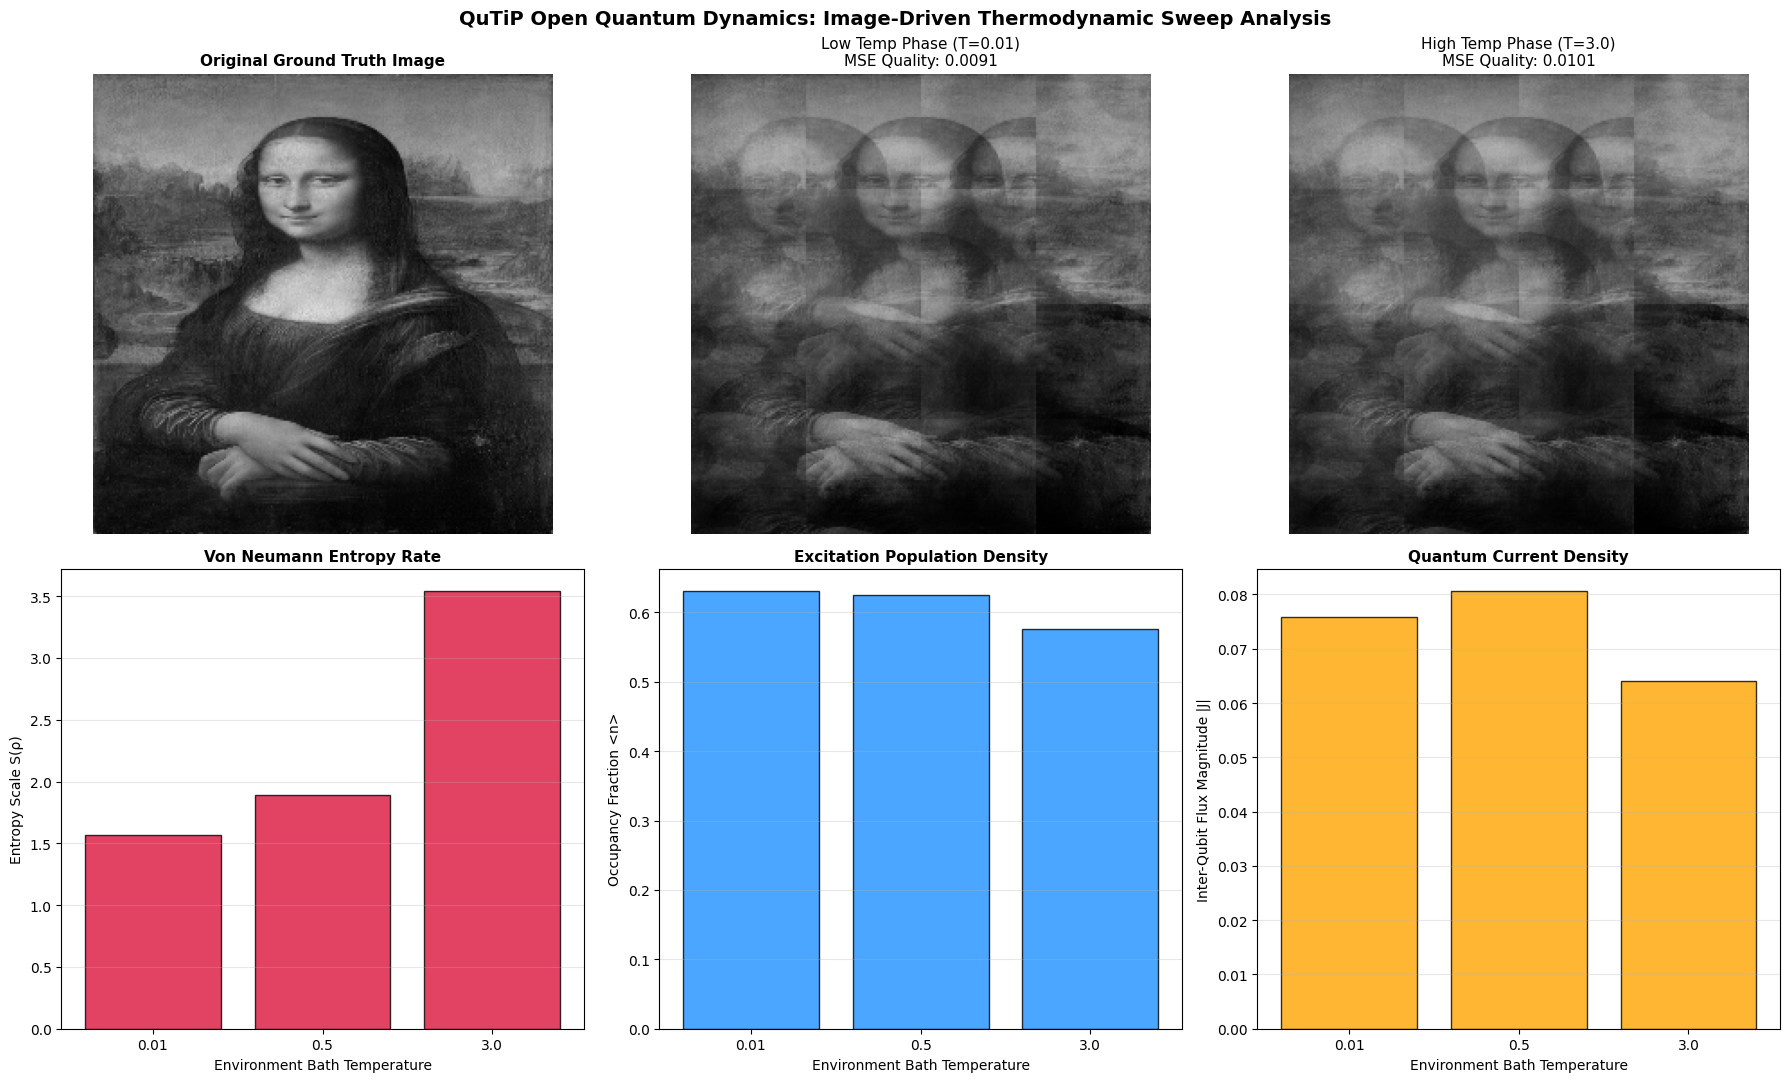

In [13]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import quimb.tensor as qtn
import qutip as qt
import matplotlib.pyplot as plt

# Force CPU for QuTiP symbolic math calculations
device = torch.device("cpu")

############################################
# 1. DATA PREPARATION & MPS COMPRESSION
############################################
try:
    img = cv2.imread("/home/adminpc/Desktop/HVK/Script/Hamiltonian_Vision_Kernel/Main/data/monalisa.jpg", cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (256, 256)).astype("float32") / 255.0
except:
    x = np.linspace(0, 1, 256)
    y = np.linspace(0, 1, 256)
    X, Y = np.meshgrid(x, y)
    img = (np.sin(X * 5) * np.cos(Y * 5) + 1) / 2.0

patch_size = 64
patches, positions_list = [], []
for i in range(0, 256, patch_size):
    for j in range(0, 256, patch_size):
        patches.append(img[i:i+patch_size, j:j+patch_size])
        positions_list.append([i / 256.0, j / 256.0])

patches = np.array(patches)
positions_np = np.array(positions_list, dtype=np.float32)
target = torch.tensor(patches, dtype=torch.float32).unsqueeze(1) # Target tensor for training

n_sites, bond_dim = 12, 4
Z_op = np.array([[1,  0], [0, -1]], dtype=complex)
X_op = np.array([[0,  1], [1,  0]], dtype=complex)

def local_expectation(mps, op, site):
    mps_c = mps.copy()
    mps_c.gate(op, site)
    return float((mps.H @ mps_c).real)

def extract_mps_features(patch: np.ndarray) -> np.ndarray:
    v = patch.flatten()
    v = v / (np.linalg.norm(v) + 1e-8)
    psi = v.reshape([2] * n_sites)
    mps = qtn.MatrixProductState.from_dense(psi)
    mps.compress(max_bond=bond_dim)
    mps.normalize()
    feats = []
    for i in range(n_sites):
        feats.append(local_expectation(mps, Z_op, i))
        feats.append(local_expectation(mps, X_op, i))
    return np.array(feats, dtype=np.float32)

print("Compressing image structures via Tensor Networks...")
features_list = [extract_mps_features(p) for p in patches]
features = np.array(features_list, dtype=np.float32)

############################################
# 2. DEFINING THE QUTIP 2D LATTICE TOPOLOGY
############################################
n_qubits = 6
edges_h = [(0, 1), (1, 2), (3, 4), (4, 5)]
edges_v = [(0, 3), (1, 4), (2, 5)]
all_edges = edges_h + edges_v

def make_qutip_op(op, qubit_idx, N=6):
    op_list = [qt.qeye(2) for _ in range(N)]
    op_list[qubit_idx] = op
    return qt.tensor(op_list)

si_z = [make_qutip_op(qt.sigmaz(), i) for i in range(n_qubits)]
si_x = [make_qutip_op(qt.sigmax(), i) for i in range(n_qubits)]
si_m = [make_qutip_op(qt.destroy(2), i) for i in range(n_qubits)]

############################################
# 3. CLASSICAL MLP PATCH DECODER BACK-END
############################################
OBS_DIM = n_qubits + n_qubits + len(all_edges) # 19
POS_ENC_DIM = 8

class ClassicalPatchDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(OBS_DIM + POS_ENC_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, patch_size * patch_size),
            nn.Sigmoid()
        )
    def forward(self, obs, pos):
        x = torch.cat([obs, pos], dim=-1)
        return self.net(x).view(-1, 1, patch_size, patch_size)

def sinusoidal_pos_enc(pos_np, d_model=POS_ENC_DIM):
    N = len(pos_np)
    enc = np.zeros((N, d_model), dtype=np.float32)
    for k in range(d_model // 4):
        freq = 1.0 / (10000 ** (4 * k / d_model))
        enc[:, 4*k+0] = np.sin(pos_np[:, 0] * freq * np.pi)
        enc[:, 4*k+1] = np.cos(pos_np[:, 0] * freq * np.pi)
        enc[:, 4*k+2] = np.sin(pos_np[:, 1] * freq * np.pi)
        enc[:, 4*k+3] = np.cos(pos_np[:, 1] * freq * np.pi)
    return torch.tensor(enc, dtype=torch.float32)

pos_enc = sinusoidal_pos_enc(positions_np)
decoder = ClassicalPatchDecoder()

def stitch(patch_arr: np.ndarray) -> np.ndarray:
    out = np.zeros((256, 256), dtype=np.float32)
    idx = 0
    for i in range(0, 256, patch_size):
        for j in range(0, 256, patch_size):
            out[i:i+patch_size, j:j+patch_size] = patch_arr[idx, 0]
            idx += 1
    return out

############################################
# 4. QUTIP OPEN QUANTUM DYNAMICS ENVIRONMENT
############################################
def run_oqs_patch_simulation(patch_feats, pos_angles, temperature):
    H_int = sum([0.5 * (si_z[u] * si_z[v]) for u, v in all_edges])
    H_ext = sum([patch_feats[i] * si_x[i] for i in range(n_qubits)])
    H = H_int + H_ext
    
    c_ops = []
    if temperature > 0:
        for i in range(n_qubits):
            omega_i = 0.5 * (i + 1)
            n_bose = 1.0 / (np.exp(omega_i / (temperature + 1e-5)) - 1.0 + 1e-8)
            gamma_down = 0.1 * (n_bose + 1)
            c_ops.append(np.sqrt(gamma_down) * si_m[i])
            gamma_up = 0.1 * n_bose
            c_ops.append(np.sqrt(gamma_up) * si_m[i].dag())
    
    tlist = np.linspace(0, 2.0, 10)
    psi0 = qt.tensor([qt.basis(2, 0) for _ in range(n_qubits)])
    
    result = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=[])
    final_rho = result.states[-1]
    
    z_vals = [qt.expect(si_z[i], final_rho) for i in range(n_qubits)]
    x_vals = [qt.expect(si_x[i], final_rho) for i in range(n_qubits)]
    zz_vals = [qt.expect(si_z[u] * si_z[v], final_rho) for u, v in all_edges]
    observables = np.array(z_vals + x_vals + zz_vals, dtype=np.float32)
    
    entropy = qt.entropy_vn(final_rho)
    population = np.mean([qt.expect(si_m[i].dag() * si_m[i], final_rho) for i in range(n_qubits)])
    
    currents = []
    for u, v in edges_h:
        comm = H * (si_z[u] * si_z[v]) - (si_z[u] * si_z[v]) * H
        current_val = complex(1j * qt.expect(comm, final_rho)).real
        currents.append(abs(current_val))
    mean_current_density = np.mean(currents) if currents else 0.0
    
    return observables, entropy, population, mean_current_density

############################################
# 5. PRE-TRAINING OPTIMIZATION LOOP
############################################
optimizer = torch.optim.Adam(decoder.parameters(), lr=0.01)
criterion = nn.MSELoss()

print("Gathering baseline quantum states at T=0 for calibration...")
baseline_obs = []
for idx in range(len(patches)):
    obs, _, _, _ = run_oqs_patch_simulation(features[idx], pos_enc[idx].numpy(), temperature=0.0)
    baseline_obs.append(obs)
baseline_obs_t = torch.tensor(np.array(baseline_obs), dtype=torch.float32)

print("Optimizing Decoder Networks parameters...")
for epoch in range(61):
    optimizer.zero_grad()
    decoded_outputs = decoder(baseline_obs_t, pos_enc)
    loss = criterion(decoded_outputs, target)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:02d} | Training Objective MSE Loss: {loss.item():.6f}")

############################################
# 6. EXECUTE THERMODYNAMIC SWEEP
############################################
T_gradient = [0.01, 0.5, 3.0]
reconstructed_images = []
macro_entropy, macro_population, macro_current, macro_mse = [], [], [], []

print("Running calibrated non-equilibrium thermal sweep...")
for T in T_gradient:
    batch_obs = []
    temp_entropy, temp_pop, temp_curr = [], [], []
    
    for idx in range(len(patches)):
        obs, s, pop, curr = run_oqs_patch_simulation(features[idx], pos_enc[idx].numpy(), T)
        batch_obs.append(obs)
        temp_entropy.append(s)
        temp_pop.append(pop)
        temp_curr.append(curr)
        
    batch_obs_t = torch.tensor(np.array(batch_obs), dtype=torch.float32)
    with torch.no_grad():
        decoded_outputs = decoder(batch_obs_t, pos_enc).numpy()
    
    recon_frame = stitch(decoded_outputs)
    reconstructed_images.append(recon_frame)
    
    macro_entropy.append(np.mean(temp_entropy))
    macro_population.append(np.mean(temp_pop))
    macro_current.append(np.mean(temp_curr))
    macro_mse.append(np.mean((img - recon_frame) ** 2))

############################################
# 7. VISUAL PRESENTATION RENDERING
############################################
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

axes[0, 0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Original Ground Truth Image", fontsize=11, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(reconstructed_images[0], cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title(f"Low Temp Phase (T={T_gradient[0]})\nMSE Quality: {macro_mse[0]:.4f}", fontsize=11)
axes[0, 1].axis("off")

axes[0, 2].imshow(reconstructed_images[2], cmap="gray", vmin=0, vmax=1)
axes[0, 2].set_title(f"High Temp Phase (T={T_gradient[2]})\nMSE Quality: {macro_mse[2]:.4f}", fontsize=11)
axes[0, 2].axis("off")

temps_str = [str(t) for t in T_gradient]

axes[1, 0].bar(temps_str, macro_entropy, color="crimson", alpha=0.8, edgecolor="black")
axes[1, 0].set_title("Von Neumann Entropy Rate", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Entropy Scale S(ρ)")
axes[1, 0].set_xlabel("Environment Bath Temperature")
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].bar(temps_str, macro_population, color="dodgerblue", alpha=0.8, edgecolor="black")
axes[1, 1].set_title("Excitation Population Density", fontsize=11, fontweight="bold")
axes[1, 1].set_ylabel("Occupancy Fraction <n>")
axes[1, 1].set_xlabel("Environment Bath Temperature")
axes[1, 1].grid(axis='y', alpha=0.3)

axes[1, 2].bar(temps_str, macro_current, color="orange", alpha=0.8, edgecolor="black")
axes[1, 2].set_title("Quantum Current Density", fontsize=11, fontweight="bold")
axes[1, 2].set_ylabel("Inter-Qubit Flux Magnitude |J|")
axes[1, 2].set_xlabel("Environment Bath Temperature")
axes[1, 2].grid(axis='y', alpha=0.3)

plt.suptitle("QuTiP Open Quantum Dynamics: Image-Driven Thermodynamic Sweep Analysis", fontsize=14, y=0.98, fontweight="bold")
plt.tight_layout()
plt.show()